# 6 Advanced Quant Projects — USA & Sri Lanka (CSE) — Google Colab

Covers, in order:
1. Mean-Variance Optimization (Markowitz — proper optimizer, not random sampling)
2. Black-Litterman Model (advanced portfolio optimization)
3. Black-Scholes Option Pricing + Greeks
4. Monte Carlo Simulation for Portfolio Returns (Geometric Brownian Motion)
5. Value at Risk (VaR) — Historical, Parametric, Monte Carlo
6. Volatility Modeling — ARCH, GARCH, EWMA

**One switch controls the market:** set `MARKET = "USA"` or `MARKET = "SRILANKA"` in the Setup cell below. Everything after Setup runs on whichever market you picked — no code duplication.

- **USA** pulls live data automatically via `yfinance`.
- **SRILANKA** uses CSV files you upload, since Yahoo Finance does not carry CSE data. Download these from cse.lk's historical data tool before running (Stock page → Historical Data → export CSV).


## Setup — run this first

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
from google.colab import files
import yfinance as yf

plt.style.use('seaborn-v0_8-darkgrid') if 'seaborn-v0_8-darkgrid' in plt.style.available else None
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# ============ SET YOUR MARKET HERE ============
MARKET = "USA"          # "USA" or "SRILANKA"
# ================================================

TRADING_DAYS = 252 if MARKET == "USA" else 240
print(f"Market set to: {MARKET} | trading days/year: {TRADING_DAYS}")

Market set to: USA | trading days/year: 252


## Data Loading

**Why this cell is separate:** every project below only needs one thing — a `prices` DataFrame (dates as index, one column per ticker) and a derived `returns` DataFrame. Isolating data loading here means the same 6 projects work on either market without touching a single line of the analysis code.


In [18]:
import time

if MARKET == "USA":
    TICKERS = ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ']
    START = '2020-01-01'
    prices = pd.DataFrame() # Initialize prices as empty DataFrame
    retries = 3
    for i in range(retries):
        try:
            # yf.download can sometimes fail due to temporary network or API issues.
            # 'auto_adjust=True' gets adjusted close prices.
            print(f"Attempt {i+1}/{retries}: Downloading data for {TICKERS}...")
            temp_prices_multi_column = yf.download(TICKERS, start=START, auto_adjust=True)

            if 'Close' in temp_prices_multi_column.columns:
                temp_prices = temp_prices_multi_column['Close']
            else:
                # If 'Close' is not a top-level column, it might be a multi-index
                # This handles cases where only one ticker is downloaded or specific yf versions
                temp_prices = temp_prices_multi_column

            # Filter out any columns that are all NaN, which might happen if a ticker download fails completely
            temp_prices = temp_prices.dropna(axis=1, how='all')
            # Drop rows where any data is missing for the remaining tickers
            prices = temp_prices.dropna()

            if not prices.empty:
                print(f"Successfully downloaded data for {len(prices.columns)} tickers.")
                break # Exit loop if download successful
            else:
                print(f"Attempt {i+1}/{retries}: Downloaded data is empty after processing. Retrying...")
                time.sleep(2) # Wait a bit before retrying
        except Exception as e:
            print(f"Attempt {i+1}/{retries}: Error during download: {e}. Retrying...")
            time.sleep(2)

    if prices.empty:
        raise ValueError("Failed to download stock data after multiple attempts. Please check ticker symbols or network connection.")

elif MARKET == "SRILANKA":
    print("Upload one CSV per CSE stock (select multiple files at once).")
    print("Suggested basket matching a typical CSE banking panel: COMB, HNB, SAMP, NDB, NTB, DFCC")
    uploaded_multi = files.upload()

    # Check one file's columns first if unsure:
    # pd.read_csv(list(uploaded_multi.keys())[0]).columns.tolist()

    DATE_COL = "Trade Date"      # <-- adjust to match YOUR CSE export's column name
    CLOSE_COL = "Close (Rs.)"    # <-- adjust to match YOUR CSE export's column name

    def load_cse_csv(filename, date_col, close_col):
        raw = pd.read_csv(filename)
        d = raw[[date_col, close_col]].copy()
        d.columns = ['Date', 'Close']
        d['Date'] = pd.to_datetime(d['Date'], dayfirst=True, errors='coerce')
        d['Close'] = pd.to_numeric(d['Close'].astype(str).str.replace(',', ''), errors='coerce')
        return d.dropna().sort_values('Date').set_index('Date')['Close']

    price_dict = {}
    for fname in uploaded_multi.keys():
        ticker_name = fname.split('.')[0]
        price_dict[ticker_name] = load_cse_csv(fname, DATE_COL, CLOSE_COL)

    prices = pd.DataFrame(price_dict).dropna()
    TICKERS = prices.columns.tolist()

else:
    raise ValueError("MARKET must be 'USA' or 'SRILANKA'")

returns = prices.pct_change().dropna()
mean_returns_annual = returns.mean() * TRADING_DAYS
cov_matrix_annual = returns.cov() * TRADING_DAYS

print(f"\nLoaded {len(TICKERS)} tickers: {TICKERS}")
prices.tail()

Attempt 1/3: Downloading data for ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ']...


[*********************100%***********************]  5 of 5 completed


Successfully downloaded data for 5 tickers.

Loaded 5 tickers: ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ']


Ticker,AAPL,JNJ,JPM,MSFT,XOM
Date,,,,,
2026-08-24,310.3400,271.7000,356.3900,487.3100,164.0500
2026-08-25,309.9000,273.1400,356.6900,491.7100,160.6400
2026-08-26,313.4500,270.0000,356.5000,496.3700,158.1900
2026-08-27,314.5800,265.7700,354.2200,505.0600,156.4400
2026-08-31,315.8000,266.3750,355.8900,511.0947,160.5150


---
# Project 1: Mean-Variance Optimization (Markowitz)

**Why this project exists:** this is the formal, optimizer-driven version of portfolio construction — instead of randomly sampling thousands of portfolios and picking the best one you happened to generate, you directly solve for the mathematically optimal weights. This is what real portfolio-construction tools do.

**What you'll get:** three optimized portfolios — Minimum Variance, Maximum Sharpe, and a full Efficient Frontier curve traced analytically (not a random dot cloud).

**Step 1.1 — Define the portfolio math as functions the optimizer can call.**


In [8]:
def port_return(w, mu):
    return np.dot(w, mu)

def port_vol(w, cov):
    return np.sqrt(np.dot(w.T, np.dot(cov, w)))

def neg_sharpe(w, mu, cov, rf=0.0):
    return -(port_return(w, mu) - rf) / port_vol(w, cov)

n = len(TICKERS)
bounds = tuple((0, 1) for _ in range(n))          # no short selling
init_guess = np.repeat(1/n, n)
constraint_sum1 = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}


**Step 1.2 — Solve for the Maximum Sharpe portfolio.**

`scipy.optimize.minimize` finds the weights that minimize *negative* Sharpe (equivalent to maximizing Sharpe), subject to weights summing to 1 and staying between 0% and 100% (no shorting).


In [30]:
rf_rate = 0.045 if MARKET == "USA" else 0.09   # approx risk-free rate: US T-bill vs LKR T-bill -- update to current

result_max_sharpe = minimize(neg_sharpe, init_guess, args=(mean_returns_annual.values, cov_matrix_annual.values, rf_rate),
                              method='SLSQP', bounds=bounds, constraints=constraint_sum1)

w_max_sharpe = result_max_sharpe.x
ret_ms = port_return(w_max_sharpe, mean_returns_annual.values)
vol_ms = port_vol(w_max_sharpe, cov_matrix_annual.values)
sharpe_ms = (ret_ms - rf_rate) / vol_ms

print("=== Maximum Sharpe Portfolio ===")
print(f"Optimizer Success: {result_max_sharpe.success}, Message: {result_max_sharpe.message}")
for t, w in zip(TICKERS, w_max_sharpe):
    print(f"  {t}: {w:.2%}")
print(f"Expected Return: {ret_ms:.2%} | Volatility: {vol_ms:.2%} | Sharpe: {sharpe_ms:.3f}")

=== Maximum Sharpe Portfolio ===
Optimizer Success: True, Message: Optimization terminated successfully
  AAPL: 32.60%
  MSFT: 22.77%
  JPM: 6.71%
  XOM: 15.71%
  JNJ: 22.21%
Expected Return: 21.93% | Volatility: 20.46% | Sharpe: 0.852


**Step 1.3 — Solve for the Minimum Variance portfolio.**

In [31]:
result_min_var = minimize(port_vol, init_guess, args=(cov_matrix_annual.values,),
                           method='SLSQP', bounds=bounds, constraints=constraint_sum1)

w_min_var = result_min_var.x
ret_mv = port_return(w_min_var, mean_returns_annual.values)
vol_mv = port_vol(w_min_var, cov_matrix_annual.values)

print("=== Minimum Variance Portfolio ===")
print(f"Optimizer Success: {result_min_var.success}, Message: {result_min_var.message}")
for t, w in zip(TICKERS, w_min_var):
    print(f"  {t}: {w:.2%}")
print(f"Expected Return: {ret_mv:.2%} | Volatility: {vol_mv:.2%}")

=== Minimum Variance Portfolio ===
Optimizer Success: True, Message: Optimization terminated successfully
  AAPL: 3.54%
  MSFT: 62.67%
  JPM: 3.99%
  XOM: 17.02%
  JNJ: 12.78%
Expected Return: 17.19% | Volatility: 17.45%


**Step 1.4 — Trace the full Efficient Frontier.**

For each target return level, find the *minimum possible* volatility portfolio that achieves it — sweeping this across many target returns traces the frontier curve exactly, rather than approximating it with random dots.


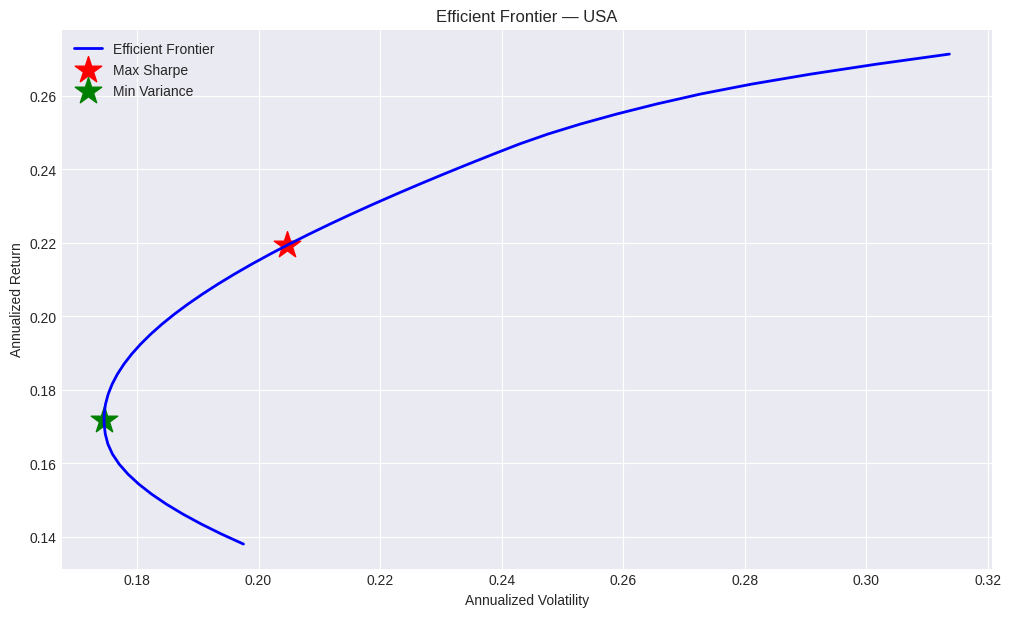

In [33]:
target_returns = np.linspace(mean_returns_annual.min(), mean_returns_annual.max(), 50)
frontier_vols = []

for target in target_returns:
    constraints = [
        constraint_sum1,
        {'type': 'eq', 'fun': lambda w, target=target: port_return(w, mean_returns_annual.values) - target}
    ]
    res = minimize(port_vol, init_guess, args=(cov_matrix_annual.values,),
                    method='SLSQP', bounds=bounds, constraints=constraints)
    frontier_vols.append(res.fun if res.success else np.nan)

plt.figure(figsize=(12,7))
plt.plot(frontier_vols, target_returns, 'b-', linewidth=2, label='Efficient Frontier')
plt.scatter(vol_ms, ret_ms, marker='*', color='red', s=400, label='Max Sharpe')
plt.scatter(vol_mv, ret_mv, marker='*', color='green', s=400, label='Min Variance')
plt.title(f'Efficient Frontier — {MARKET}')
plt.xlabel('Annualized Volatility'); plt.ylabel('Annualized Return')
plt.legend()
plt.show()


**Beginner checkpoint:** The Max Sharpe portfolio isn't necessarily on the frontier's midpoint — it's the point where a line from the risk-free rate is *tangent* to the frontier curve (the Capital Market Line). Everything above and left of it on that tangent line is theoretically achievable by mixing the Max Sharpe portfolio with a risk-free asset — that's the actual insight behind "Tangency Portfolio" you may have seen in textbooks.

---
# Project 2: Black-Litterman Model (Advanced Technique)

**Why this project exists:** pure Markowitz optimization (Project 1) has a well-known weakness — it's extremely sensitive to the input expected returns, and historical average returns are noisy, unstable estimates. Small changes in `mean_returns_annual` can flip the optimal weights entirely. Black-Litterman fixes this by starting from a stable, market-implied baseline and blending in your own views only where you actually have a view — rather than forcing you to specify a return forecast for every single asset.

**What you'll get:** a new set of expected returns (blending market equilibrium + your views) and a new optimized portfolio, comparable side-by-side against Project 1's pure-historical-return version.

**Step 2.1 — Get market-cap weights (the "equilibrium" starting point).**


In [34]:
if MARKET == "USA":
    market_caps = {}
    for t in TICKERS:
        try:
            market_caps[t] = yf.Ticker(t).info.get('marketCap', np.nan)
        except Exception:
            market_caps[t] = np.nan
    mc = pd.Series(market_caps)
    if mc.isna().any():
        print("Some market caps unavailable -- falling back to equal weights.")
        w_market = np.repeat(1/n, n)
    else:
        w_market = (mc / mc.sum()).values
else:
    # CSE market caps aren't fetchable automatically here -- replace with real figures if you have them,
    # e.g. w_market = np.array([0.30, 0.20, 0.15, 0.15, 0.10, 0.10])  # must sum to 1, one value per ticker
    print("No automatic market-cap source for CSE -- using equal weights as the equilibrium proxy.")
    print("Replace w_market below with real free-float market-cap weights if you have them.")
    w_market = np.repeat(1/n, n)

print("Market weights used as equilibrium prior:")
for t, w in zip(TICKERS, w_market):
    print(f"  {t}: {w:.2%}")


Market weights used as equilibrium prior:
  AAPL: 43.27%
  MSFT: 35.62%
  JPM: 8.88%
  XOM: 6.19%
  JNJ: 6.03%


**Step 2.2 — Reverse-optimize to get implied equilibrium returns (π).**

Instead of asking "given expected returns, what's the optimal portfolio?" (Project 1's direction), Black-Litterman runs the question backwards: "given the market-cap weights everyone already holds, what expected returns would make THAT portfolio optimal?" That output, π (pi), is a much more stable starting point than raw historical averages.


In [35]:
market_var = np.dot(w_market.T, np.dot(cov_matrix_annual.values, w_market))
market_ret = np.dot(w_market, mean_returns_annual.values)
delta = (market_ret - rf_rate) / market_var   # implied risk-aversion coefficient

pi = delta * np.dot(cov_matrix_annual.values, w_market)   # implied equilibrium returns

print("Implied equilibrium returns (pi):")
for t, p in zip(TICKERS, pi):
    print(f"  {t}: {p:.2%}")


Implied equilibrium returns (pi):
  AAPL: 23.26%
  MSFT: 10.28%
  JPM: 15.11%
  XOM: 16.61%
  JNJ: 11.81%


**Step 2.3 — Add your own view(s).**

Example: "I believe TICKERS[0] will return 5 percentage points MORE than the market-implied equilibrium suggests." This is an absolute view on one asset — edit `VIEW_TICKER` and `VIEW_RETURN` to reflect an actual view you hold (e.g. from your own equity research).


In [36]:
VIEW_TICKER = TICKERS[0]
VIEW_RETURN = pi[TICKERS.index(VIEW_TICKER)] + 0.05   # example: equilibrium + 5pp
VIEW_CONFIDENCE = 0.5   # 0 = no confidence (ignored), 1 = very high confidence

P = np.zeros((1, n))
P[0, TICKERS.index(VIEW_TICKER)] = 1
Q = np.array([VIEW_RETURN])

tau = 0.05
omega = np.array([[ (1/VIEW_CONFIDENCE - 1) * np.dot(P, np.dot(tau*cov_matrix_annual.values, P.T))[0,0] ]])

print(f"View: {VIEW_TICKER} expected return = {VIEW_RETURN:.2%} (confidence={VIEW_CONFIDENCE})")


View: AAPL expected return = 28.26% (confidence=0.5)


**Step 2.4 — Blend equilibrium returns with your view (the Black-Litterman formula).**

In [37]:
tau_sigma = tau * cov_matrix_annual.values
inv_term = np.linalg.inv(np.linalg.inv(tau_sigma) + P.T @ np.linalg.inv(omega) @ P)
bl_returns = inv_term @ (np.linalg.inv(tau_sigma) @ pi + P.T @ np.linalg.inv(omega) @ Q)

comparison = pd.DataFrame({
    'Historical Avg Return': mean_returns_annual.values,
    'Equilibrium (pi)': pi,
    'Black-Litterman (blended)': bl_returns
}, index=TICKERS)
comparison


,Historical Avg Return,Equilibrium (pi),Black-Litterman (blended)
AAPL,0.2714,0.2326,0.2576
MSFT,0.1380,0.1028,0.1075
JPM,0.2134,0.1511,0.1610
XOM,0.2294,0.1661,0.1816
JNJ,0.2208,0.1181,0.1248


**Step 2.5 — Re-optimize the portfolio using the Black-Litterman returns instead of raw historical returns.**

In [38]:
result_bl = minimize(neg_sharpe, init_guess, args=(bl_returns, cov_matrix_annual.values, rf_rate),
                     method='SLSQP', bounds=bounds, constraints=constraint_sum1)
w_bl = result_bl.x

weight_comparison = pd.DataFrame({
    'Market Cap Weights': w_market,
    'Pure MVO (Project 1) Max Sharpe': w_max_sharpe,
    'Black-Litterman Max Sharpe': w_bl
}, index=TICKERS)
weight_comparison


,Market Cap Weights,Pure MVO (Project 1) Max Sharpe,Black-Litterman Max Sharpe
AAPL,0.4327,0.3260,0.6948
MSFT,0.3562,0.2277,0.1803
JPM,0.0888,0.0671,0.1065
XOM,0.0619,0.1571,0.0000
JNJ,0.0603,0.2221,0.0185


**Beginner checkpoint:** Notice the Black-Litterman weights sit *between* the market-cap weights and the pure-MVO weights, rather than matching either extreme — that's the model working as intended. Pure MVO can produce extreme, concentrated, unstable allocations when historical returns are noisy; Black-Litterman "pulls" the result back toward the stable market equilibrium except where you explicitly stated a view. The stronger your `VIEW_CONFIDENCE`, the further the result shifts toward your view.

---
# Project 3: Black-Scholes Option Pricing + Greeks

**Why this project exists:** the reference closed-form model for pricing European options and the benchmark every more advanced pricing method (binomial, Monte Carlo, stochastic vol) is compared against.

**What you'll get:** a call/put price for a real stock from your loaded data, a parity check confirming the formula is correct, the four core Greeks, and a payoff curve.


In [39]:
def black_scholes(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
    return price, d1, d2

def greeks(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    gamma = norm.pdf(d1) / (S*sigma*np.sqrt(T))
    vega  = S*norm.pdf(d1)*np.sqrt(T) / 100
    if option_type == 'call':
        delta = norm.cdf(d1)
        theta = (-(S*norm.pdf(d1)*sigma)/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2)) / 365
    else:
        delta = norm.cdf(d1) - 1
        theta = (-(S*norm.pdf(d1)*sigma)/(2*np.sqrt(T)) + r*K*np.exp(-r*T)*norm.cdf(-d2)) / 365
    return {'Delta': delta, 'Gamma': gamma, 'Vega': vega, 'Theta (per day)': theta}

# Use the first ticker in your loaded data
OPT_TICKER = TICKERS[0]
S = prices[OPT_TICKER].iloc[-1]
K = round(S / 5) * 5
T = 1.0
r = rf_rate
sigma = returns[OPT_TICKER].std() * np.sqrt(TRADING_DAYS)

call_price, d1, d2 = black_scholes(S, K, T, r, sigma, 'call')
put_price, _, _ = black_scholes(S, K, T, r, sigma, 'put')

print(f"{OPT_TICKER} | Spot: {S:.2f} | Strike: {K:.2f} | Annualized vol: {sigma:.2%}")
print(f"Call price: {call_price:.4f} | Put price: {put_price:.4f}")

lhs = call_price - put_price
rhs = S - K*np.exp(-r*T)
print(f"\nPut-call parity check: {lhs:.4f} vs {rhs:.4f} | Match: {np.isclose(lhs, rhs)}")

print(f"\nCall Greeks: {greeks(S, K, T, r, sigma, 'call')}")
print(f"Put Greeks:  {greeks(S, K, T, r, sigma, 'put')}")


AAPL | Spot: 315.80 | Strike: 315.00 | Annualized vol: 31.37%
Call price: 46.2154 | Put price: 31.5546

Put-call parity check: 14.6608 vs 14.6608 | Match: True

Call Greeks: {'Delta': np.float64(0.6211052513091616), 'Gamma': np.float64(0.0038398667504072337), 'Vega': np.float64(1.2013545737101736), 'Theta (per day)': np.float64(-0.07011174917938537)}
Put Greeks:  {'Delta': np.float64(-0.3788947486908384), 'Gamma': np.float64(0.0038398667504072337), 'Vega': np.float64(1.2013545737101736), 'Theta (per day)': np.float64(-0.03298499765888074)}


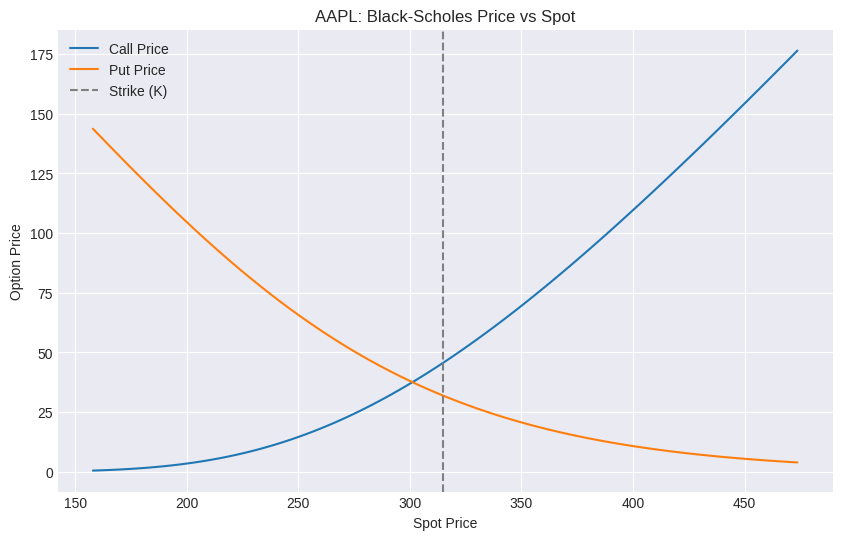

In [40]:
spots = np.linspace(S*0.5, S*1.5, 100)
call_curve = [black_scholes(s, K, T, r, sigma, 'call')[0] for s in spots]
put_curve  = [black_scholes(s, K, T, r, sigma, 'put')[0] for s in spots]

plt.figure(figsize=(10,6))
plt.plot(spots, call_curve, label='Call Price')
plt.plot(spots, put_curve, label='Put Price')
plt.axvline(K, color='gray', linestyle='--', label='Strike (K)')
plt.title(f'{OPT_TICKER}: Black-Scholes Price vs Spot')
plt.xlabel('Spot Price'); plt.ylabel('Option Price')
plt.legend()
plt.show()


**Beginner checkpoint:** if `MARKET == "SRILANKA"`, remember CSE has no liquid listed equity options market today — this is a modeling exercise using CSE stock volatility, not something directly tradeable there yet.

---
# Project 4: Monte Carlo Simulation for Portfolio Returns (Geometric Brownian Motion)

**Why this project exists:** instead of one deterministic forecast, GBM simulation generates thousands of *possible future paths* for your portfolio, given its historical drift and volatility (and the correlations between assets). This gives you a full distribution of outcomes rather than a single number — much closer to how real risk/scenario analysis works.

**What you'll get:** a "fan chart" of thousands of simulated portfolio value paths, plus the distribution of final outcomes.

**Step 4.1 — Set up correlated random shocks using Cholesky decomposition.**

Individual GBM paths need to respect the real correlation between assets — simulating each stock independently would understate portfolio risk. Cholesky decomposition of the covariance matrix lets us generate correlated random shocks.


In [41]:
n_days = 252
n_sims = 1000
dt = 1/TRADING_DAYS

mu = returns.mean().values          # daily mean return per asset
cov_daily = returns.cov().values    # daily covariance matrix
L = np.linalg.cholesky(cov_daily)   # Cholesky factor

weights = w_max_sharpe   # use Project 1's optimized portfolio
S0 = prices.iloc[-1].values


**Step 4.2 — Run the simulation.**

In [42]:
portfolio_paths = np.zeros((n_days, n_sims))

for sim in range(n_sims):
    Z = np.random.normal(size=(n_days, len(TICKERS)))
    correlated_shocks = Z @ L.T
    price_paths = np.zeros((n_days, len(TICKERS)))
    price_paths[0] = S0

    for day in range(1, n_days):
        drift = (mu - 0.5*np.diag(cov_daily))
        price_paths[day] = price_paths[day-1] * np.exp(drift + correlated_shocks[day])

    # Portfolio value assuming initial LKR/USD 1 invested per weight
    normalized = price_paths / S0
    portfolio_value = normalized @ weights
    portfolio_paths[:, sim] = portfolio_value


**Step 4.3 — Plot the fan chart and the distribution of outcomes.**

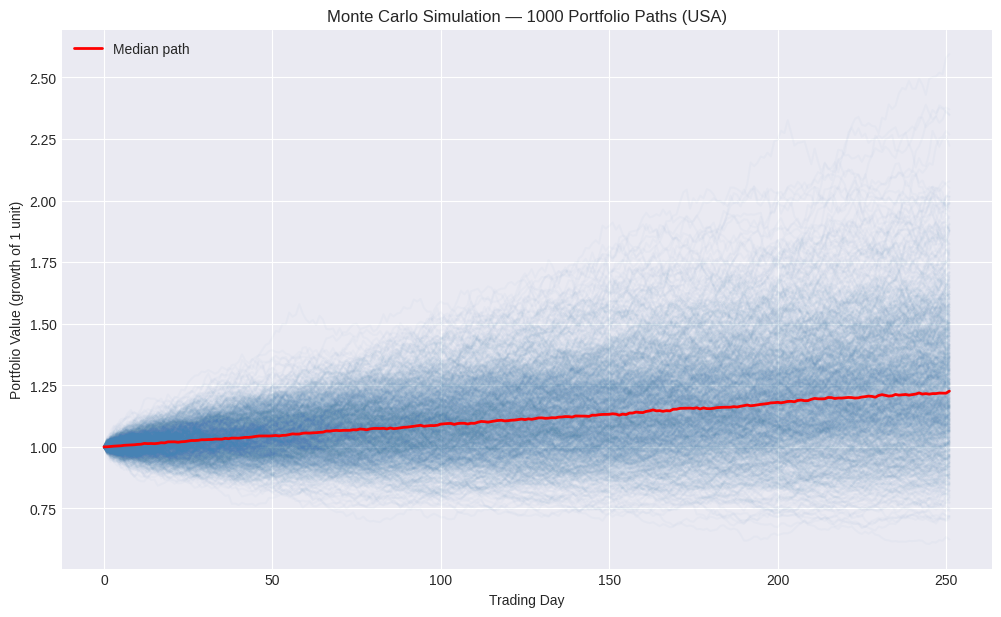

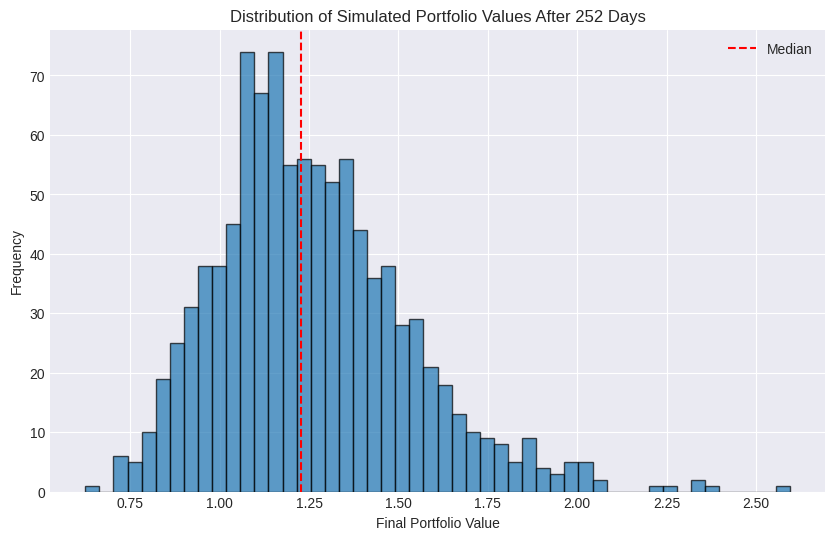

Median outcome: 1.226
5th percentile (bad case):  0.880
95th percentile (good case): 1.758


In [43]:
plt.figure(figsize=(12,7))
plt.plot(portfolio_paths, color='steelblue', alpha=0.03)
plt.plot(np.median(portfolio_paths, axis=1), color='red', linewidth=2, label='Median path')
plt.title(f'Monte Carlo Simulation — {n_sims} Portfolio Paths ({MARKET})')
plt.xlabel('Trading Day'); plt.ylabel('Portfolio Value (growth of 1 unit)')
plt.legend()
plt.show()

final_values = portfolio_paths[-1, :]
plt.figure(figsize=(10,6))
plt.hist(final_values, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(np.median(final_values), color='red', linestyle='--', label='Median')
plt.title(f'Distribution of Simulated Portfolio Values After {n_days} Days')
plt.xlabel('Final Portfolio Value'); plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"Median outcome: {np.median(final_values):.3f}")
print(f"5th percentile (bad case):  {np.percentile(final_values, 5):.3f}")
print(f"95th percentile (good case): {np.percentile(final_values, 95):.3f}")


**Beginner checkpoint:** the widening "fan" shape isn't a modeling artifact — it's the correct behavior of GBM. Uncertainty compounds over time (variance grows linearly with time under GBM, so the spread of outcomes grows with the square root of time), which is exactly why long-horizon forecasts are inherently less precise than short-horizon ones, regardless of how good your model is.

---
# Project 5: Value at Risk (VaR) — Historical, Parametric, Monte Carlo

**Why this project exists:** measures the portfolio's downside directly, using three different methods on the same data so you can see how much the answer depends on your modeling assumptions.

**What you'll get:** three VaR estimates plus Conditional VaR (Expected Shortfall), computed on Project 1's Max Sharpe portfolio.


In [44]:
portfolio_returns = returns.dot(w_max_sharpe)
confidence = 0.95

# Historical VaR
historical_var = np.percentile(portfolio_returns, (1 - confidence) * 100)

# Parametric VaR
mu_p = portfolio_returns.mean()
sigma_p = portfolio_returns.std()
z = norm.ppf(1 - confidence)
parametric_var = mu_p + z * sigma_p

# Monte Carlo VaR (reusing Project 4's simulated final-day portfolio returns for consistency)
daily_sim_returns = np.diff(np.log(portfolio_paths), axis=0).flatten()
mc_var = np.percentile(daily_sim_returns, (1 - confidence) * 100)

print(f"1-day Historical VaR  ({confidence:.0%}): {historical_var:.4%}")
print(f"1-day Parametric VaR  ({confidence:.0%}): {parametric_var:.4%}")
print(f"1-day Monte Carlo VaR ({confidence:.0%}): {mc_var:.4%}")

breach_returns = portfolio_returns[portfolio_returns <= historical_var]
cvar = breach_returns.mean()
print(f"\nCVaR / Expected Shortfall: {cvar:.4%}")


1-day Historical VaR  (95%): -1.7357%
1-day Parametric VaR  (95%): -2.0331%
1-day Monte Carlo VaR (95%): -2.0543%

CVaR / Expected Shortfall: -3.0199%


**Beginner checkpoint:** the Monte Carlo VaR here is now genuinely connected to Project 4's simulation (not a separately re-simulated number) — this is what a real risk pipeline looks like: one consistent simulation engine feeding multiple risk metrics, rather than each metric computed in isolation.

---
# Project 6: Volatility Modeling — ARCH, GARCH, EWMA

**Why this project exists:** every prior project assumed volatility is constant (a single `sigma` number). In reality volatility clusters — calm periods and turbulent periods group together — and GARCH-family models capture that directly, which matters enormously for risk management and options pricing.

**What you'll get:** three different volatility estimates over time for one stock — a simple rolling estimate, EWMA (RiskMetrics-style), and a fitted GARCH(1,1) model with its own forward forecast.

**Step 6.1 — Pick a stock and compute simple rolling volatility as a baseline.**


In [45]:
from arch import arch_model

VOL_TICKER = TICKERS[0]
r = returns[VOL_TICKER] * 100   # arch library expects returns in percentage points

rolling_vol = r.rolling(20).std()


**Step 6.2 — EWMA (Exponentially Weighted Moving Average) volatility.**

RiskMetrics' standard approach: each day's variance estimate is a weighted blend of yesterday's variance estimate and today's squared return, with more weight on recent data (λ=0.94 is the RiskMetrics industry-standard decay factor).


In [46]:
lam = 0.94
ewma_var = np.zeros(len(r))
ewma_var[0] = r.iloc[:20].var()

for t in range(1, len(r)):
    ewma_var[t] = lam * ewma_var[t-1] + (1 - lam) * r.iloc[t-1]**2

ewma_vol = pd.Series(np.sqrt(ewma_var), index=r.index)


**Step 6.3 — Fit a GARCH(1,1) model.**

In [47]:
garch_model = arch_model(r, vol='Garch', p=1, q=1, dist='normal')
garch_fit = garch_model.fit(disp='off')
print(garch_fit.summary())

garch_vol = garch_fit.conditional_volatility


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   AAPL   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3333.48
Distribution:                  Normal   AIC:                           6674.96
Method:            Maximum Likelihood   BIC:                           6696.65
                                        No. Observations:                 1672
Date:                Mon, Aug 31 2026   Df Residuals:                     1671
Time:                        18:32:22   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1400  4.310e-02      3.247  1.164e-03 [5.549e-0

**Step 6.4 — Plot all three volatility estimates together.**

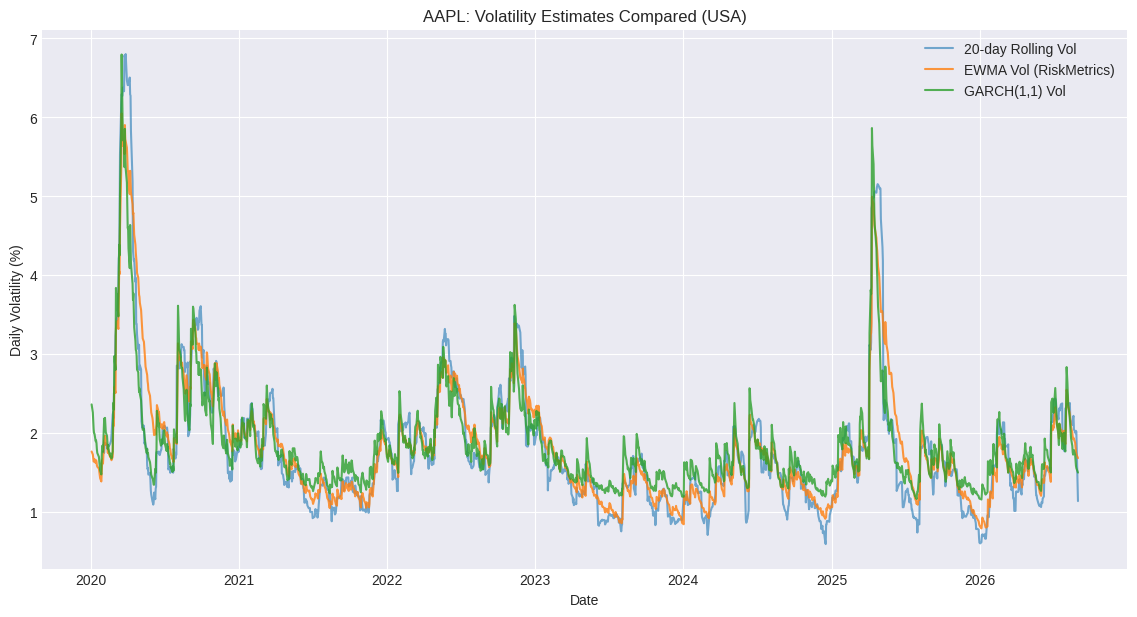

In [48]:
plt.figure(figsize=(14,7))
plt.plot(rolling_vol.index, rolling_vol, label='20-day Rolling Vol', alpha=0.6)
plt.plot(ewma_vol.index, ewma_vol, label='EWMA Vol (RiskMetrics)', alpha=0.8)
plt.plot(garch_vol.index, garch_vol, label='GARCH(1,1) Vol', alpha=0.8)
plt.title(f'{VOL_TICKER}: Volatility Estimates Compared ({MARKET})')
plt.xlabel('Date'); plt.ylabel('Daily Volatility (%)')
plt.legend()
plt.show()


**Step 6.5 — Forecast volatility forward using GARCH.**

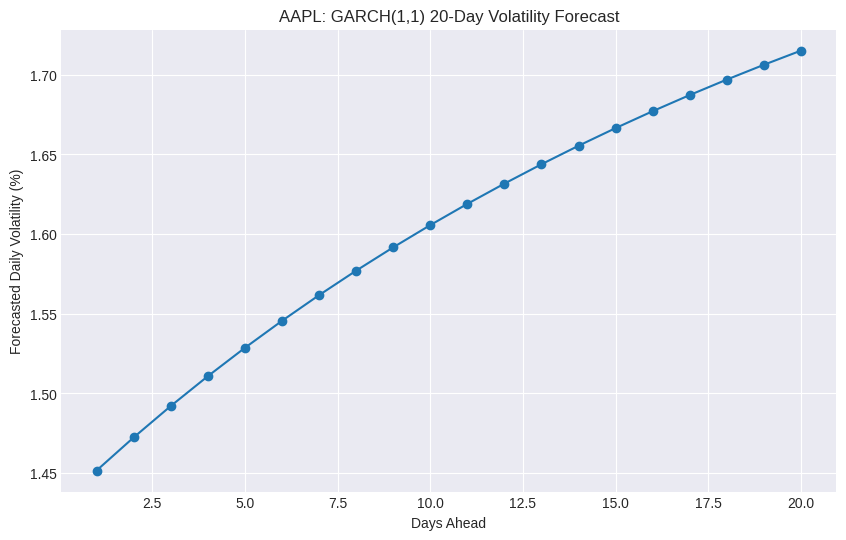

Current GARCH volatility: 1.502%
Forecasted volatility in 20 days: 1.715%


In [49]:
forecast_horizon = 20
forecast = garch_fit.forecast(horizon=forecast_horizon)
forecast_vol = np.sqrt(forecast.variance.values[-1])

plt.figure(figsize=(10,6))
plt.plot(range(1, forecast_horizon+1), forecast_vol, marker='o')
plt.title(f'{VOL_TICKER}: GARCH(1,1) {forecast_horizon}-Day Volatility Forecast')
plt.xlabel('Days Ahead'); plt.ylabel('Forecasted Daily Volatility (%)')
plt.show()

print(f"Current GARCH volatility: {garch_vol.iloc[-1]:.3f}%")
print(f"Forecasted volatility in {forecast_horizon} days: {forecast_vol[-1]:.3f}%")


**Beginner checkpoint:** GARCH volatility should visibly spike around known stress periods (e.g. COVID crash for USA stocks, or 2022 around Sri Lanka's sovereign default for CSE stocks) and decay afterward — that decay pattern (volatility clustering + mean reversion) is exactly what a constant-sigma assumption in Project 3's Black-Scholes model misses. If `MARKET == "SRILANKA"`, compare the GARCH spike timing directly against your dissertation's documented regime-instability window around the 2022 default.

---
## Wrap-up

Six projects, one shared data pipeline, two markets:

| Project | What it answers |
|---|---|
| 1. Mean-Variance Optimization | What's the mathematically optimal portfolio given historical risk/return? |
| 2. Black-Litterman | How do I combine market equilibrium with my own views, without pure-MVO's instability? |
| 3. Black-Scholes + Greeks | What should an option cost, and how does that value move? |
| 4. Monte Carlo (GBM) | What's the full distribution of possible portfolio outcomes, not just one forecast? |
| 5. VaR / CVaR | How bad could a bad day be, measured three different ways? |
| 6. ARCH/GARCH/EWMA | How does risk itself change over time, rather than staying constant? |

**Natural extension given your dissertation:** swap Project 6's GARCH-forecasted volatility into Project 3's Black-Scholes `sigma` input instead of a static historical figure — that's a direct, practical use of volatility forecasting in option pricing, and ties your existing forecasting-model work (ARIMAX/CatBoost) into a derivatives-pricing context.
